<a href="https://colab.research.google.com/github/edwincas4240-ctrl/inteligencia-artificial-2/blob/main/Untitled7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

¡Librerías importadas correctamente!

--- EJECUTANDO EJEMPLO 1: ÁRBOL DE DECISIÓN ---
Predicción para el nuevo día: Ir a Correr



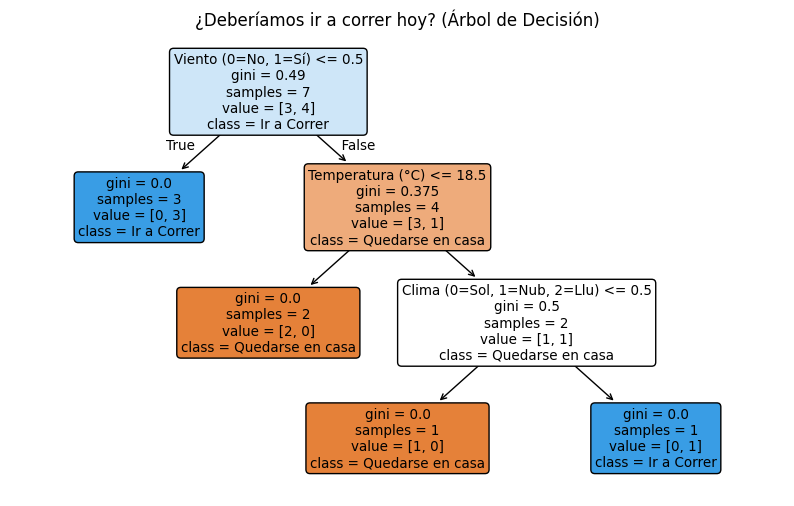



--- EJECUTANDO EJEMPLO 2: RANDOM FOREST ---
El comité del banco ha decidido: ¡El crédito está APROBADO 🎉!
Porcentaje de votos a favor del comité: 90.0%


In [2]:
# ==========================================
# PROYECTO: ÁRBOLES DE DECISIÓN Y RANDOM FOREST
# Ejemplos aplicados a la vida cotidiana
# ==========================================

# 1. IMPORTAR LIBRERÍAS NECESARIAS
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

print("¡Librerías importadas correctamente!\n")

# ==========================================
# EJEMPLO 1: ÁRBOL DE DECISIÓN (Caja Blanca)
# Situación: ¿Salimos a correr hoy?
# ==========================================

print("--- EJECUTANDO EJEMPLO 1: ÁRBOL DE DECISIÓN ---")

# Datos simulados [Clima, Temperatura (°C), Viento]
# Clima: 0=Soleado, 1=Nublado, 2=Lluvioso | Viento: 0=No, 1=Sí
X_vida_real = np.array([
    [0, 25, 0],  # Soleado, 25°C, Sin viento -> SÍ corremos (1)
    [0, 32, 1],  # Soleado, 32°C, Con viento -> NO corremos (0)
    [1, 20, 0],  # Nublado, 20°C, Sin viento -> SÍ corremos (1)
    [2, 15, 1],  # Lluvioso, 15°C, Con viento -> NO corremos (0)
    [1, 22, 1],  # Nublado, 22°C, Con viento -> SÍ corremos (1)
    [2, 12, 1],  # Lluvioso, 12°C, Con viento -> NO corremos (0)
    [0, 28, 0],  # Soleado, 28°C, Sin viento -> SÍ corremos (1)
])

# Etiquetas: 1 = Ir a correr, 0 = Quedarse en casa
y_vida_real = np.array([1, 0, 1, 0, 1, 0, 1])

# Nombres descriptivos para las características y clases
caracteristicas = ['Clima (0=Sol, 1=Nub, 2=Llu)', 'Temperatura (°C)', 'Viento (0=No, 1=Sí)']
clases = ['Quedarse en casa', 'Ir a Correr']

# Entrenamos el Árbol de Decisión
arbol_cotidiano = DecisionTreeClassifier(max_depth=3, random_state=42)
arbol_cotidiano.fit(X_vida_real, y_vida_real)

# Probamos con un nuevo escenario: Día Soleado (0), a 30°C y sin viento (0)
nuevo_dia = np.array([[0, 30, 0]])
prediccion_arbol = arbol_cotidiano.predict(nuevo_dia)

print(f"Predicción para el nuevo día: {clases[prediccion_arbol[0]]}\n")

# Visualizamos gráficamente el árbol
plt.figure(figsize=(10, 6))
plot_tree(
    arbol_cotidiano,
    feature_names=caracteristicas,
    class_names=clases,
    filled=True,
    rounded=True
)
plt.title("¿Deberíamos ir a correr hoy? (Árbol de Decisión)")
plt.show()

print("\n" + "="*50 + "\n")

# ==========================================
# EJEMPLO 2: BOSQUE ALEATORIO (Random Forest)
# Situación: Comité del banco para aprobar un crédito
# ==========================================

print("--- EJECUTANDO EJEMPLO 2: RANDOM FOREST ---")

# Datos de clientes [Ingresos mensuales (miles), Historial crediticio (0=Malo, 1=Bueno), Deudas pendientes (0=No, 1=Sí)]
X_credito = np.array([
    [1.5, 0, 1],  # Bajos ingresos, mal historial, con deudas -> Rechazado (0)
    [4.0, 1, 0],  # Buenos ingresos, buen historial, sin deudas -> Aprobado (1)
    [2.0, 0, 0],  # Bajos ingresos, mal historial, sin deudas -> Rechazado (0)
    [5.5, 1, 0],  # Altos ingresos, buen historial, sin deudas -> Aprobado (1)
    [3.0, 1, 1],  # Ingresos medios, buen historial, con deudas -> Aprobado (1)
    [1.0, 0, 1],  # Bajos ingresos, mal historial, con deudas -> Rechazado (0)
    [6.0, 1, 0],  # Altos ingresos, buen historial, sin deudas -> Aprobado (1)
])

# Etiquetas: 1 = Crédito Aprobado, 0 = Crédito Rechazado
y_credito = np.array([0, 1, 0, 1, 1, 0, 1])

# Creamos el Bosque Aleatorio (un comité de 50 árboles/asesores)
comite_banco = RandomForestClassifier(
    n_estimators=50,  # Cantidad de árboles en el bosque
    max_depth=3,
    random_state=42
)

# Entrenamos el modelo
comite_banco.fit(X_credito, y_credito)

# Simulamos un nuevo cliente que solicita crédito: [Ingresos: 3.5 mil, Historial: Bueno (1), Deudas: No (0)]
cliente_nuevo = np.array([[3.5, 1, 0]])
resultado_comite = comite_banco.predict(cliente_nuevo)

estado_credito = "APROBADO 🎉" if resultado_comite[0] == 1 else "RECHAZADO ❌"
print(f"El comité del banco ha decidido: ¡El crédito está {estado_credito}!")

# Consultamos la votación interna del bosque
probabilidad = comite_banco.predict_proba(cliente_nuevo)
print(f"Porcentaje de votos a favor del comité: {probabilidad[0][1]*100:.1f}%")